<a href="https://colab.research.google.com/github/sgulyano/imgvdoproc/blob/main/lab_optical_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Optical Flow Object Tracking

***In this lab, we will study how to use Optical Flow to track a sample object from an image sequence or video.***

Optical Flow represents the motion of images across consecutive frames. The method generally relies on changes in pixel intensity values and is described as a set of 2D vectors indicating how each pixel moves to a new position in the next frame. This technique is based on two main assumptions:

1. The intensity of a pixel belonging to the same object remains constant between frames, and
2. Pixels within a local neighborhood tend to move in a similar manner.

In this lab, we will use Gunnar Farneback's algorithm [2, 3] to compute Optical Flow. The result is Dense Optical Flow, meaning that every pixel in the image has a vector indicating the direction in which that pixel moves in the next frame. This differs from Sparse Optical Flow, which provides displacement vectors only for selected pixels with distinctive features.


**References**
1. https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html
2. Farneback, G. “Two-Frame Motion Estimation Based on Polynomial Expansion.” In Proceedings of the 13th Scandinavian Conference on Image Analysis, 363 - 370. Halmstad, Sweden: SCIA, 2003.
3. https://www.mathworks.com/help/vision/ref/opticalflowfarneback.html

## 1. Prepare Data

First, download the sample car video from https://github.com/savnani5/Optical-Flow-Motion

In [ ]:
!wget -O "cars_on_highway.mp4" https://drive.google.com/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa&export=download

--2023-05-24 09:53:30--  https://drive.google.com/u/1/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa
Resolving drive.google.com (drive.google.com)... 142.251.2.138, 142.251.2.101, 142.251.2.113, ...
Connecting to drive.google.com (drive.google.com)|142.251.2.138|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://drive.google.com/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa [following]
--2023-05-24 09:53:30--  https://drive.google.com/uc?id=1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa
Reusing existing connection to drive.google.com:443.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-00-6o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/cpoath4q37eu3chu1bfsr58v85h01hah/1684921950000/11797005964751114850/*/1TEfEyGDJvn8NSa7xUS5THI9HIkpTINCa?uuid=22bfb467-9aa8-4403-98cb-60f7265b8c4a [following]
--2023-05-24 09:53:31--  https://doc-00-6o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/cpoath4q37eu3c

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

Open the video file using the `VideoCapture` function

In [ ]:
cap = cv2.VideoCapture("cars_on_highway.mp4")
ret, frame1 = cap.read()
width = frame1.shape[1]
height = frame1.shape[0]

Create images to store annotations of the car's motion position in each frame, and store the Optical Flow for each frame.

In [ ]:
mask = np.zeros_like(frame1)

hsv = np.zeros_like(frame1)
hsv[...,1] = 255

Open files to save the car tracking results in each frame and the computed Optical Flow, and create a function to draw the Optical Flow overlaid on the image.

In [ ]:
out = cv2.VideoWriter('cars_track.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width,height))
out_opf = cv2.VideoWriter('cars_flow.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 20, (width,height))

In [ ]:
def draw_flow(img, flow, step=25):
    h, w = img.shape[:2]
    y, x = np.mgrid[step/2:h:step, step/2:w:step].reshape(2,-1).astype(int)
    fx, fy = flow[y,x].T
    lines = np.vstack([x, y, x+fx, y+fy]).T.reshape(-1, 2, 2)
    lines = np.int32(lines + 0.5)
    vis = img
    cv2.polylines(vis, lines, 0, (0, 255, 0), 2)
    for (x1, y1), (x2, y2) in lines:
        cv2.circle(vis, (x1, y1), 2, (0, 0, 255), -1)
    return vis

Input the position of the object or car to be tracked in the initial frame, and specify the color for the annotation.

In [ ]:
prvs = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)

p0 = np.array([[[930,700]],
               [[760,500]],
               [[700,380]],
               [[590,340]],
               [[1020,380]],
               [[1360,560]],
               [[330,320]]], dtype='float32')
color = np.random.randint(0, 255, (7, 3))

## 2. Optical Flow Computation and Object Tracking

After that, for each frame, perform the following steps:

1. Compute the Optical Flow for that frame.
2. Estimate the position of the object in the next frame.
3. Save the results, and update the frame and the object position.

In [ ]:
while(1):
    ret, frame2 = cap.read()

    if ret == True:
        width = frame1.shape[1]
        height = frame1.shape[0]

        # calculate optical flow
        next = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prvs,next, None, 0.5, 3, 15, 3, 5, 1.2, 0)

        # calculate new objects' positions
        p1 = p0 + flow[np.int16(np.round(p0[:,:,1])), np.int16(np.round(p0[:,:,0])),:]
        p1[:,:,0] = np.clip(p1[:,:,0], 0, width-1)
        p1[:,:,1] = np.clip(p1[:,:,1], 0, height-1)

        # draw the tracks
        img = frame2
        for i, (new, old) in enumerate(zip(p1, p0)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 5)
            img = cv2.circle(img, (int(a), int(b)), 10, color[i].tolist(), -1)
        img = cv2.add(img, mask)

        # draw the optical flow
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        hsv[...,0] = ang*180/np.pi/2
        hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
        bgr = cv2.cvtColor(hsv,cv2.COLOR_HSV2BGR)
        frame3 = draw_flow(frame2, flow)

        # save to vdo file
        out.write(img)
        out_opf.write(frame3)

        # update frame and objects' positions
        prvs = next
        p0 = p1
    else:
        break
cap.release()
out.release()
out_opf.release()
print('done')

done


Display the tracking results of the cars, where each line represents the motion trajectory of one object.

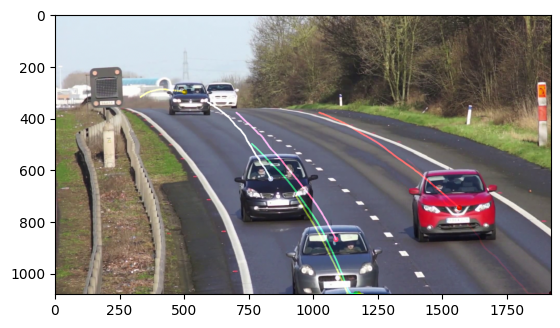

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255)

## 3. Displaying the Results

To make the output viewable in Colab, use `ffmpeg` to compress the video and display it using HTML.

In [ ]:
from IPython.display import HTML
from base64 import b64encode

In [ ]:
!ffmpeg -y -i cars_track.mp4  -vcodec libx264  cars_track_compress.mp4

ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

In [ ]:
mp4 = open('cars_track_compress.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=600 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [ ]:
!ffmpeg -y -i cars_flow.mp4  -vcodec libx264  cars_flow_compress.mp4

ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

In [ ]:
mp4 = open('cars_flow_compress.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=1000 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

----